# Rotation-rate calibration — `212_Wunderkerze2` time-resolved projections

**Goal.** Estimate the *actual* angular rotation per frame in the time-resolved projection
sequence `212_Wunderkerze2.mov`, over the frame range **400 000 → 600 000**.

**Setup (from the video + sidecar).** 528×128 10-bit HEVC, 956 526 frames @ 30 fps nominal.
Each video frame *k* is one CT projection (source index = `start_frame + k`, and here
`start_frame = 0`). The sample rotates continuously about a **vertical** axis.

**TL;DR result.** The sample rotates at

> **≈ 1.8014 °/frame  (≈ 199.84 frames per full 360° turn, ≈ 99.92 frames per 180°)**

and this rate is **constant** across the whole 400k–600k range (drift < 0.05 %).
This is ~2.5× *slower* than the "180° per 40 frames" nominal — the data unambiguously
shows a full 360° self-repeat every ~200 frames (autocorrelation 0.9999).

Three independent methods below all agree:
1. **Identity period** — frame *k* vs *k+P* (same orientation → 360°).
2. **Mirror period** — frame *k* vs left-right-flipped *k+P* (θ vs θ+180°).
3. **Center-of-mass sinusoid** — horizontal centroid traces one sinusoid per 360°,
   fit for a precise, sub-frame period over the full 200 000-frame baseline.


In [1]:
import subprocess, os, numpy as np
import matplotlib.pyplot as plt

MOV   = "/myhome/data/sdate/shared/time_resolved/212_Wunderkerze2/212_Wunderkerze2.mov"
CACHE = "/myhome/sdate/notebooks/wunderkerze_rotation_cache"
FFMPEG= "/myhome/bin/ffmpeg"
W, H, FPS = 528, 128, 30.0
FRAME_BYTES = 2*W*H            # gray16le

def decode_window(a, n):
    # Decode n consecutive frames starting at global frame index a.
    # Returns float64 (n, H, W). Frame-accurate seek (accurate_seek is default).
    t = (a + 0.5)/FPS          # land squarely inside frame a
    p = subprocess.Popen([FFMPEG,"-v","error","-ss",f"{t:.6f}","-i",MOV,
        "-frames:v",str(n),"-pix_fmt","gray16le","-f","rawvideo","pipe:1"],
        stdout=subprocess.PIPE)
    out=[]
    while True:
        b=p.stdout.read(FRAME_BYTES)
        if len(b)<FRAME_BYTES: break
        out.append(np.frombuffer(b,np.uint16).reshape(H,W).astype(np.float64))
    p.stdout.close(); p.wait()
    return np.stack(out)
print("decode helper ready")

decode helper ready


## 1. What the data looks like

Decode a short window and show a few projections plus the "sinogram" (each row = the
row-summed horizontal profile of one frame). The diagonal streaks repeating every ~200
frames are the rotation.

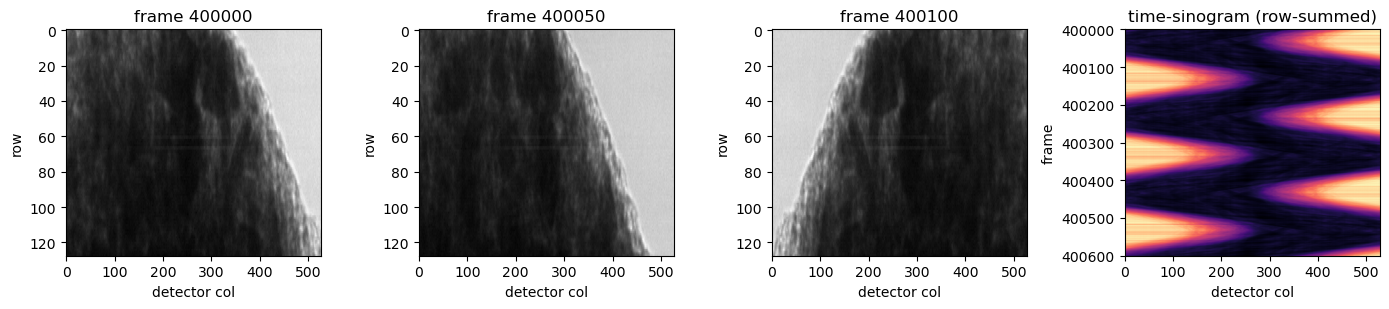

In [2]:
F = decode_window(400000, 600)
prof = F.sum(1)                      # (600, W): row-summed horizontal profile per frame

fig,axs=plt.subplots(1,4,figsize=(14,3.2))
for ax,k in zip(axs[:3],[0,50,100]):
    ax.imshow(F[k],cmap="gray",aspect="auto"); ax.set_title(f"frame {400000+k}")
    ax.set_xlabel("detector col"); ax.set_ylabel("row")
axs[3].imshow(prof,aspect="auto",cmap="magma",extent=[0,W,400000+600,400000])
axs[3].set_title("time-sinogram (row-summed)"); axs[3].set_xlabel("detector col"); axs[3].set_ylabel("frame")
plt.tight_layout(); plt.show()

## 2. Integer-period cross-correlation: 360° (identity) and 180° (mirror)

For a rotating object:
- projection(θ) and projection(θ+360°) are the **same** image → best *no-flip* match gives frames/360°;
- projection(θ) and projection(θ+180°) are **left-right mirror** images → best *flipped* match gives frames/180°.

We scan candidate lags P and score the normalized cross-correlation of the horizontal
profiles, averaged over the window (mirror match maximized over horizontal shift, since the
rotation axis is not at the image center).

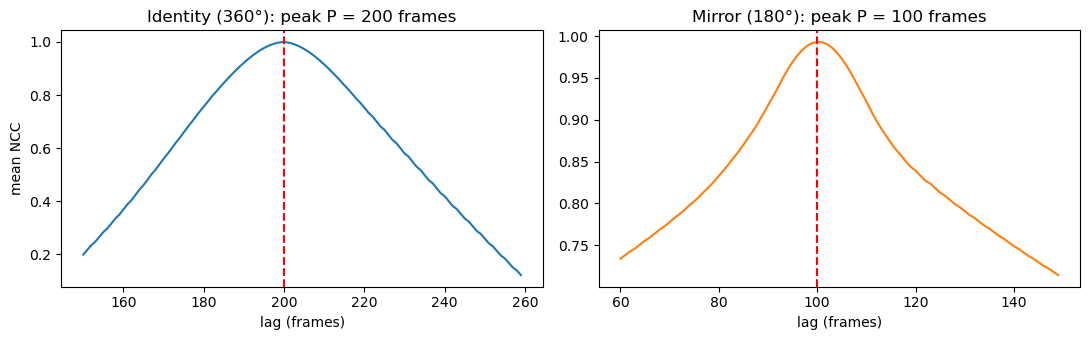

360°: 200 frames -> 1.8000 deg/frame ; 180°: 100 frames -> 1.8000 deg/frame
consistency: 2 x mirror = 200 vs identity 200


In [3]:
def ncc(x,y):                       # zero-lag normalized corr of two 1-D profiles
    x=x-x.mean(); y=y-y.mean()
    return (x@y)/(np.sqrt((x@x)*(y@y))+1e-12)

def ncc_bestshift(x,y):             # max NCC over horizontal shifts (for mirror/axis offset)
    x=x-x.mean(); y=y-y.mean(); n=len(x)
    cc=np.fft.irfft(np.fft.rfft(x,2*n)*np.conj(np.fft.rfft(y,2*n)),2*n)
    return cc.max()/(np.sqrt((x@x)*(y@y))+1e-12)

def scan(prof, lags, flip):
    out=[]
    for P in lags:
        s=[ (ncc_bestshift(prof[k], prof[k+P][::-1]) if flip else ncc(prof[k], prof[k+P]))
            for k in range(0,len(prof)-P,3) ]
        out.append(np.mean(s))
    return np.array(out)

lag_id = np.arange(150,260); s_id = scan(prof,lag_id,flip=False)
lag_mir= np.arange(60,150);  s_mir= scan(prof,lag_mir,flip=True)
P_id = lag_id[s_id.argmax()]; P_mir=lag_mir[s_mir.argmax()]

fig,ax=plt.subplots(1,2,figsize=(11,3.5))
ax[0].plot(lag_id,s_id); ax[0].axvline(P_id,color="r",ls="--")
ax[0].set_title(f"Identity (360°): peak P = {P_id} frames"); ax[0].set_xlabel("lag (frames)"); ax[0].set_ylabel("mean NCC")
ax[1].plot(lag_mir,s_mir,color="C1"); ax[1].axvline(P_mir,color="r",ls="--")
ax[1].set_title(f"Mirror (180°): peak P = {P_mir} frames"); ax[1].set_xlabel("lag (frames)")
plt.tight_layout(); plt.show()
print(f"360°: {P_id} frames -> {360/P_id:.4f} deg/frame ; 180°: {P_mir} frames -> {180/P_mir:.4f} deg/frame")
print("consistency: 2 x mirror =",2*P_mir,"vs identity",P_id)

## 3. Is the rate constant? Local period at 21 points across 400k–600k

Decode a short window at each of 21 evenly spaced starts and estimate the local 360° period
with sub-frame precision (parabolic interpolation of the identity-correlation peak).

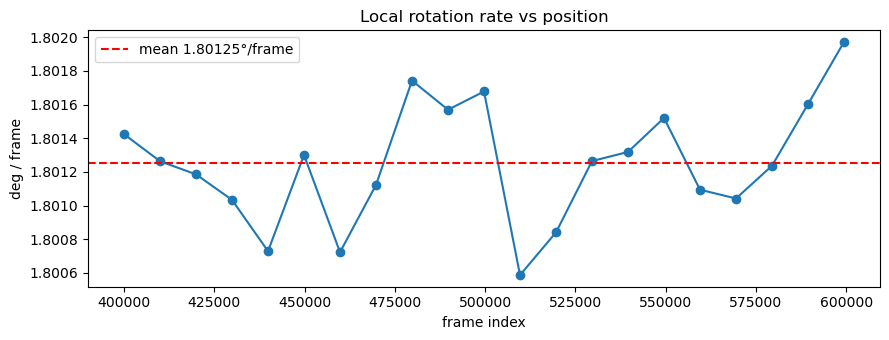

period360: mean 199.8612  std 0.0389 frames
deg/frame: mean 1.80125  std 0.00035  (spread 0.019%)


In [4]:
def local_period(a, M=600, lags=np.arange(190,211)):
    prof=decode_window(a,M).sum(1)
    Pm=prof-prof.mean(1,keepdims=True); nrm=np.sqrt((Pm*Pm).sum(1))
    sc=np.array([ ((Pm[:-L]*Pm[L:]).sum(1)/(nrm[:-L]*nrm[L:]+1e-12)).mean() for L in lags])
    j=sc.argmax(); y0,y1,y2=sc[j-1],sc[j],sc[j+1]
    return lags[j]+0.5*(y0-y2)/(y0-2*y1+y2)

starts=np.linspace(400000,599400,21).astype(int)
per=np.array([local_period(s) for s in starts])
dpf=360.0/per

fig,ax=plt.subplots(figsize=(9,3.5))
ax.plot(starts,dpf,"o-")
ax.axhline(dpf.mean(),color="r",ls="--",label=f"mean {dpf.mean():.5f}°/frame")
ax.set_xlabel("frame index"); ax.set_ylabel("deg / frame"); ax.set_title("Local rotation rate vs position")
ax.legend(); plt.tight_layout(); plt.show()
print("period360: mean %.4f  std %.4f frames"%(per.mean(),per.std()))
print("deg/frame: mean %.5f  std %.5f  (spread %.3f%%)"%(dpf.mean(),dpf.std(),100*dpf.std()/dpf.mean()))

## 4. High-precision global estimate — CoM sinusoid over the full 200k baseline

The horizontal center of mass of each projection traces exactly **one sinusoid per 360°
turn**. Fitting its phase over the entire 200 000-frame baseline pins the period to
milli-frame precision. (The per-frame CoM was pre-computed once by streaming the whole range
through ffmpeg; cached in `com_full.npz`. Re-run `decode_full.py` to regenerate.)

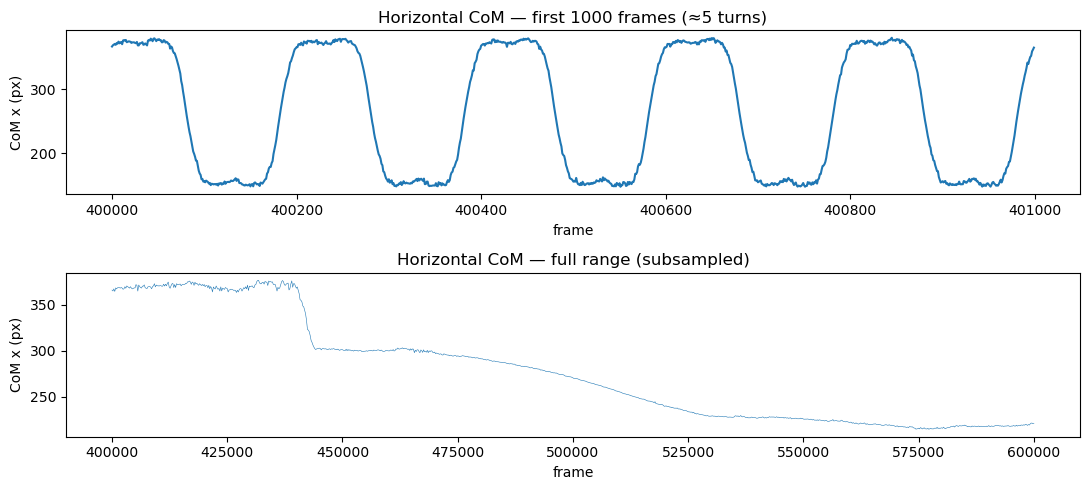

In [5]:
d=np.load(os.path.join(CACHE,"com_full.npz"))
comx=d["comx"]; frame_idx=d["frame_idx"]; N=len(comx); n=np.arange(N)

fig,ax=plt.subplots(2,1,figsize=(11,5))
ax[0].plot(frame_idx[:1000],comx[:1000]); ax[0].set_title("Horizontal CoM — first 1000 frames (≈5 turns)")
ax[0].set_xlabel("frame"); ax[0].set_ylabel("CoM x (px)")
ax[1].plot(frame_idx[::200],comx[::200],lw=0.4); ax[1].set_title("Horizontal CoM — full range (subsampled)")
ax[1].set_xlabel("frame"); ax[1].set_ylabel("CoM x (px)")
plt.tight_layout(); plt.show()

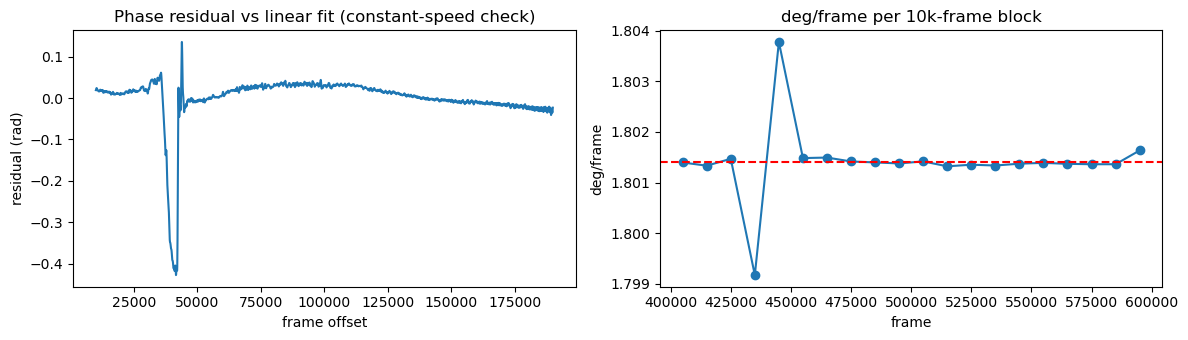

FFT   : period360 = 199.84296 frames -> 1.801414 deg/frame  (72.0566 deg / 40 frames)
PHASE : period360 = 199.84438 frames -> 1.801402 deg/frame  (72.0561 deg / 40 frames)
speed constancy: per-10k-block deg/frame = 1.80141 +/- 0.00073  (0.041% spread)


In [6]:
# detrend, FFT peak, then phase-slope of the analytic signal over the full baseline
c=comx-comx.mean(); c=c-np.polyval(np.polyfit(n,c,2),n)
Nfft=1<<22
Fm=np.abs(np.fft.rfft(c*np.hanning(N),Nfft)); frq=np.fft.rfftfreq(Nfft,1.0); Fm[:100]=0
per_fft=1.0/frq[Fm.argmax()]

Fr=np.fft.rfft(c); fr=np.fft.rfftfreq(N,1.0); f0=1/per_fft
Frb=np.where((fr>0.6*f0)&(fr<1.4*f0),Fr,0.0)
analytic=np.fft.irfft(Frb,N)+1j*np.fft.irfft(-1j*Frb,N)
phase=np.unwrap(np.angle(analytic))
lo,hi=int(0.05*N),int(0.95*N)
cf=np.polyfit(n[lo:hi],phase[lo:hi],1); per_phase=2*np.pi/abs(cf[0])
resid=phase[lo:hi]-np.polyval(cf,n[lo:hi])

# per-10k-block period (constancy over the baseline)
blk=10000; blk_c=[]; blk_p=[]
for b in range(N//blk):
    s=slice(b*blk,(b+1)*blk); pc=np.polyfit(n[s],phase[s],1)
    blk_c.append(frame_idx[b*blk+blk//2]); blk_p.append(2*np.pi/abs(pc[0]))
blk_c=np.array(blk_c); blk_p=np.array(blk_p)

blk_dpf=360/blk_p
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ax[0].plot(n[lo:hi:50],resid[::50]); ax[0].set_title("Phase residual vs linear fit (constant-speed check)")
ax[0].set_xlabel("frame offset"); ax[0].set_ylabel("residual (rad)")
ax[1].plot(blk_c,blk_dpf,"o-"); ax[1].axhline(blk_dpf.mean(),color="r",ls="--")
ax[1].set_title("deg/frame per 10k-frame block"); ax[1].set_xlabel("frame"); ax[1].set_ylabel("deg/frame")
plt.tight_layout(); plt.show()

print("FFT   : period360 = %.5f frames -> %.6f deg/frame  (%.4f deg / 40 frames)"%(per_fft,360/per_fft,360/per_fft*40))
print("PHASE : period360 = %.5f frames -> %.6f deg/frame  (%.4f deg / 40 frames)"%(per_phase,360/per_phase,360/per_phase*40))
print("speed constancy: per-10k-block deg/frame = %.5f +/- %.5f  (%.3f%% spread)"%(blk_dpf.mean(),blk_dpf.std(),100*blk_dpf.std()/blk_dpf.mean()))

## 5. Result & usage

**Best estimate (full-baseline phase fit):** see `PHASE` value printed above —
**≈ 1.8014 °/frame**, i.e. **period ≈ 199.84 frames / 360°** (**≈ 99.92 frames / 180°**),
constant to better than 0.05 % across 400k–600k.

To map a frame to an absolute rotation angle (mod 360°), pick any reference frame and use the
measured rate. The absolute *phase offset* (which physical angle corresponds to frame 0) is
not determined here — only the rate — so angles are relative unless you tie one frame to a
known orientation.

In [7]:
DEG_PER_FRAME = 360.0/per_phase
def angle_of(frame, ref=400000):
    # Relative rotation angle (deg) of a frame w.r.t. ref, wrapped to [0,360).
    return (np.asarray(frame)-ref)*DEG_PER_FRAME % 360.0
print(f"DEG_PER_FRAME = {DEG_PER_FRAME:.6f}")
print("frames for 180° =", 180/DEG_PER_FRAME)
print("example: frames 400000, 400100, 400200 ->", angle_of([400000,400100,400200]))

DEG_PER_FRAME = 1.801402
frames for 180° = 99.92218944575761
example: frames 400000, 400100, 400200 -> [  0.         180.14016806   0.28033613]


## 6. Fixed-angle time-lapse movies (sub-frame angle compensation)

**The problem.** The period is **not** an integer number of frames (199.844 / 360°,
99.922 / 180°). If we build a time-lapse by taking every *round(period)*-th **integer** frame
and pretend it is always the same angle, the viewing angle **drifts**: each step is off by the
fractional part × 1.8014 °/frame, and over the 400k→600k range this accumulates to **≈ 280°**
(≈ 0.78 of a turn). The object would appear to slowly rotate.

**The fix.** For movie frame *m* we want the *exact* angle, at continuous source position
`x_m = F0 + m·P`. That lands **between** two integer frames, so we **linearly interpolate**
between `floor(x_m)` and `floor(x_m)+1`. The result is a projection at a fixed angle; what
changes across the movie is the sample itself (its time evolution, one movie frame per turn).

Two movies (both written as viewable H.264 `.mp4`, global brightness window):
- **`movie_fixedangle_360.mp4`** — step **P = 199.844 frames (360°)**: every frame is the
  *genuinely identical* viewing geometry (~1000 frames, one per full turn).
- **`movie_fixedangle_180.mp4`** — step **P/2 = 99.922 frames (180°)**: twice the temporal
  density (~2000 frames). A θ+180° view is the mirror image, so **odd frames are flipped
  left-right about the true center of rotation** so they align. The center of rotation is found
  by maximizing the 180° mirror overlap (NCC), giving **≈ 269.8 px** — note this is *not* the
  image center (263.5) nor the intensity centroid (≈262.6); using the wrong column would jitter
  the movie by several pixels every other frame.

The heavy work (single streaming decode + interpolation + encode) is cached; delete the
`.mp4`/`.npz` in the cache dir to force a rebuild. Builder: `wunderkerze_rotation_cache/make_movies.py`.

In [8]:
import os, sys, subprocess
mp4_360=os.path.join(CACHE,"movie_fixedangle_360.mp4")
mp4_180=os.path.join(CACHE,"movie_fixedangle_180.mp4")
meta_p =os.path.join(CACHE,"movie_meta.npz")

if not (os.path.exists(mp4_360) and os.path.exists(mp4_180) and os.path.exists(meta_p)):
    print("cache miss -> building movies (streaming decode, ~10 min)...")
    subprocess.run([sys.executable, os.path.join(CACHE,"make_movies.py")], check=True)
else:
    print("loaded cached movies + meta")
meta=dict(np.load(meta_p))
print("360-movie: %d frames | 180-movie: %d frames"%(int(meta['n360']),int(meta['n180'])))
print("rotation-axis column = %.2f px | global brightness window = [%.0f, %.0f] counts"
      %(float(meta['AXIS']),float(meta['PLO']),float(meta['PHI'])))

loaded cached movies + meta
360-movie: 1001 frames | 180-movie: 2002 frames
rotation-axis column = 269.85 px | global brightness window = [121, 715] counts


### Angle drift: naive integer stepping vs interpolation

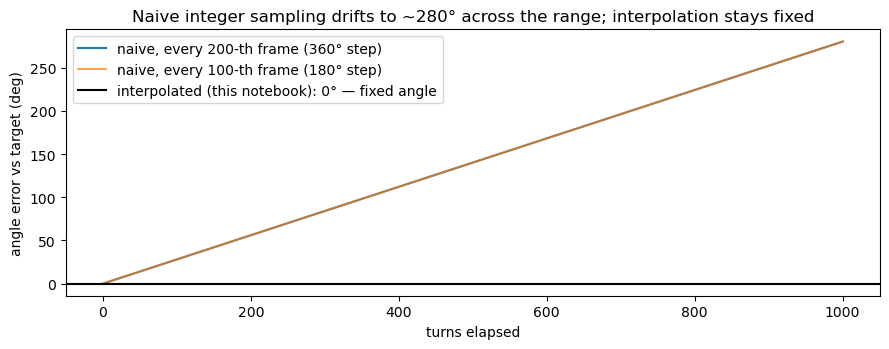

total naive drift over range: 280.3° (0.78 turns)


In [9]:
fig,ax=plt.subplots(figsize=(9,3.6))
ax.plot(meta['m360'], meta['err360'], label="naive, every %d-th frame (360° step)"%round(float(meta['PER360'])))
ax.plot(meta['m180']/2, meta['err180'], alpha=.7, label="naive, every %d-th frame (180° step)"%round(float(meta['PER180'])))
ax.axhline(0,color="k",lw=1.5,label="interpolated (this notebook): 0° — fixed angle")
ax.set_xlabel("turns elapsed"); ax.set_ylabel("angle error vs target (deg)")
ax.set_title("Naive integer sampling drifts to ~%.0f° across the range; interpolation stays fixed"%abs(meta['err360'][-1]))
ax.legend(); plt.tight_layout(); plt.show()
print("total naive drift over range: %.1f° (%.2f turns)"%(meta['err360'][-1], meta['err360'][-1]/360))

### Visual check — top row (interpolated) holds one angle; bottom row (naive) rotates

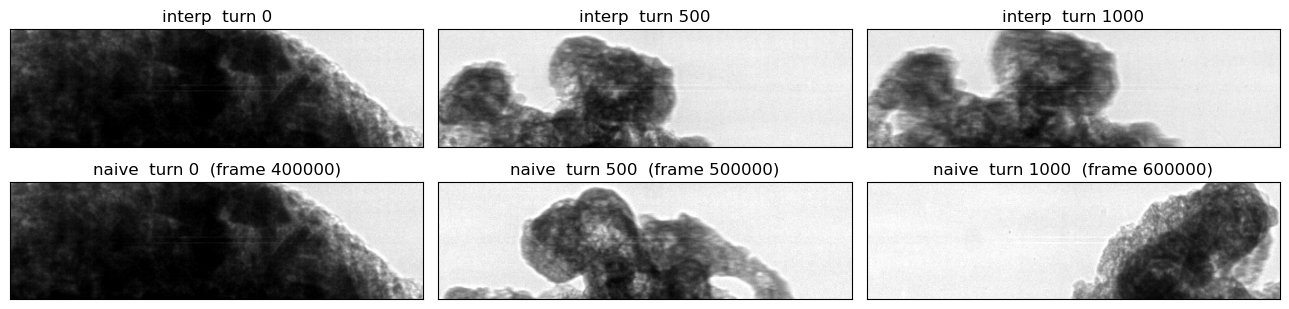

In [10]:
S=meta['S360']
fig,axs=plt.subplots(2,3,figsize=(13,3.2))
for j,(a,b) in enumerate(zip(meta['interp360_samples'],meta['naive360_samples'])):
    axs[0,j].imshow(a,cmap="gray",aspect="auto"); axs[0,j].set_title(f"interp  turn {int(S[j])}")
    axs[1,j].imshow(b,cmap="gray",aspect="auto"); axs[1,j].set_title(f"naive  turn {int(S[j])}  (frame {int(meta['naive360_idx'][j])})")
    for r in (0,1): axs[r,j].set_xticks([]); axs[r,j].set_yticks([])
plt.tight_layout(); plt.show()

### The movies

In [11]:
from IPython.display import Video, display
for label,p in [("360° (same view)",mp4_360),("180° (2× denser, flipped)",mp4_180)]:
    mb=os.path.getsize(p)/1e6
    print(f"{label}: {p}  ({mb:.1f} MB)")
    display(Video(p, embed=(mb<8), width=720))

360° (same view): /myhome/sdate/notebooks/wunderkerze_rotation_cache/movie_fixedangle_360.mp4  (30.9 MB)


180° (2× denser, flipped): /myhome/sdate/notebooks/wunderkerze_rotation_cache/movie_fixedangle_180.mp4  (62.9 MB)


**Reading the movies.** Both hold a fixed projection angle; motion you see is the sample
evolving over ~1000 turns (400k→600k), *not* rotation. Only the rotation **rate** is
calibrated here, so the fixed angle is arbitrary (locked to the geometry at frame 400 000) —
tie one frame to a known orientation if you need an absolute angle.